In [ ]:
# In[1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

In [ ]:
# In[2]:

data = pd.read_csv("car_prices.csv", nrows = 100000)
data.head()

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500,21500,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800,21500,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900,30000,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500,27750,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000,67000,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


In [ ]:
# In[3]:

data.shape

(100000, 16)

In [ ]:
# In[4]:

data = data.drop(['vin', 'trim','saledate','state', 'mmr'], axis = 1)
data.shape

(100000, 11)

In [ ]:
# In[5]:

100*data.isnull().sum()/len(data)

year             0.000
make             0.425
model            0.443
body             2.731
transmission    12.000
condition       11.792
odometer         0.075
color            0.183
interior         0.183
seller           0.000
sellingprice     0.000
dtype: float64

In [ ]:
# In[6]:

data.describe()

,year,condition,odometer,sellingprice
count,100000.000000,88208.000000,99925.000000,100000.000000
mean,2009.293750,29.489037,75147.522172,12230.463520
std,4.256992,13.804882,57711.981006,9333.910641
min,1984.000000,1.000000,1.000000,1.000000
25%,2006.000000,21.000000,29568.000000,5100.000000
50%,2011.000000,33.000000,60953.000000,11000.000000
75%,2013.000000,41.000000,110618.000000,16900.000000
max,2015.000000,49.000000,999999.000000,156000.000000


In [ ]:
# In[7]:

data['condition'].fillna(data['condition'].mean(), inplace=True)
data['odometer'].fillna(data['odometer'].mean(), inplace=True)
data['sellingprice'].fillna(data['sellingprice'].mean(), inplace=True)
data['make'].fillna(data['make'].mode()[0], inplace=True)
data['model'].fillna(data['model'].mode()[0], inplace=True)
data['body'].fillna(data['body'].mode()[0], inplace=True)
data['transmission'].fillna(data['transmission'].mode()[0], inplace=True)
data['color'].fillna(data['color'].mode()[0], inplace=True)
data['interior'].fillna(data['interior'].mode()[0], inplace=True)
data['seller'].fillna(data['seller'].mode()[0], inplace = True)

In [ ]:
# In[8]:

100*data.isnull().sum()/len(data)

year            0.0
make            0.0
model           0.0
body            0.0
transmission    0.0
condition       0.0
odometer        0.0
color           0.0
interior        0.0
seller          0.0
sellingprice    0.0
dtype: float64

In [ ]:
# In[9]:

data['make'] = pd.factorize(data['make'])[0]
data['model'] = pd.factorize(data['model'])[0]
data['body'] = pd.factorize(data['body'])[0]
data['transmission'] = pd.factorize(data['transmission'])[0]
data['color'] = pd.factorize(data['color'])[0]
data['interior'] = pd.factorize(data['interior'])[0]
data['seller'] = pd.factorize(data['seller'])[0]

data.describe()

,year,make,model,body,transmission,condition,odometer,color,interior,seller,sellingprice
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,2009.293750,14.575760,164.212160,3.031270,0.033340,29.489037,75147.522172,3.321690,1.947260,1358.616930,12230.463520
std,4.256992,12.923668,141.570016,5.129976,0.179524,12.965414,57690.334737,3.324818,1.977412,1779.973036,9333.910641
min,1984.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,2006.000000,4.000000,59.000000,0.000000,0.000000,24.000000,29582.750000,1.000000,0.000000,59.000000,5100.000000
50%,2011.000000,9.000000,157.000000,1.000000,0.000000,29.489037,61022.500000,2.000000,2.000000,727.500000,11000.000000
75%,2013.000000,23.000000,205.000000,3.000000,0.000000,39.000000,110590.250000,4.000000,4.000000,1959.000000,16900.000000
max,2015.000000,92.000000,878.000000,42.000000,1.000000,49.000000,999999.000000,19.000000,16.000000,7086.000000,156000.000000


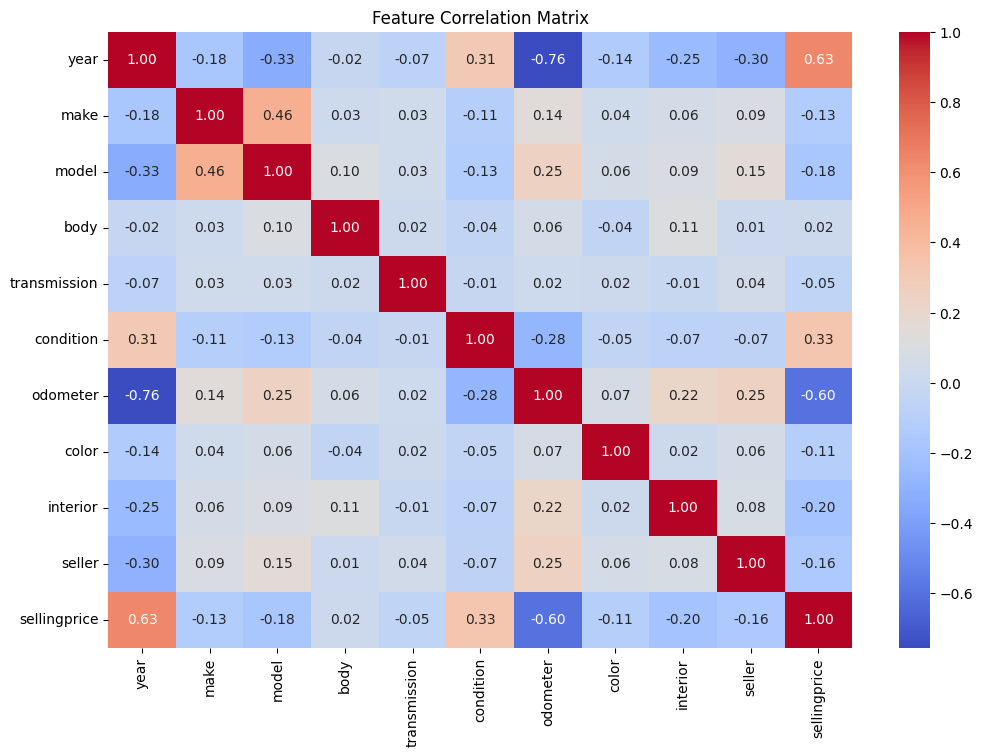

                year           make          model           body  \
count  100000.000000  100000.000000  100000.000000  100000.000000   
mean     2009.293750      14.575760     164.212160       3.031270   
std         4.256992      12.923668     141.570016       5.129976   
min      1984.000000       0.000000       0.000000       0.000000   
25%      2006.000000       4.000000      59.000000       0.000000   
50%      2011.000000       9.000000     157.000000       1.000000   
75%      2013.000000      23.000000     205.000000       3.000000   
max      2015.000000      92.000000     878.000000      42.000000   

        transmission      condition       odometer          color  \
count  100000.000000  100000.000000  100000.000000  100000.000000   
mean        0.033340      29.489037   75147.522172       3.321690   
std         0.179524      12.965414   57690.334737       3.324818   
min         0.000000       1.000000       1.000000       0.000000   
25%         0.000000      24.0000

In [ ]:
# In[10]:

correlation_matrix = data.corr()
plt.figure(figsize=(12, 8))  # Adjust the figure size as needed
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Feature Correlation Matrix")
plt.show()
print(data.describe())

In [ ]:
# In[11]:

data = data.drop(['make', 'body', 'model', 'transmission', 'color'], axis = 1)

In [ ]:
# In[12]:

data = data[data['odometer'] < 500000]
data['odometer'] = np.log1p(data['odometer']) 
data['seller']= np.log1p(data['seller'])

In [ ]:
# In[13]:

X = data.drop('sellingprice', axis = 1)
y = data['sellingprice']

In [ ]:
# In[14]:

norm = MinMaxScaler().fit(X)
X = norm.transform(X)

Mean Squared Error:  39259703.42
Root Mean Squared Error:  6265.76
Mean Absolute Error:  4103.68


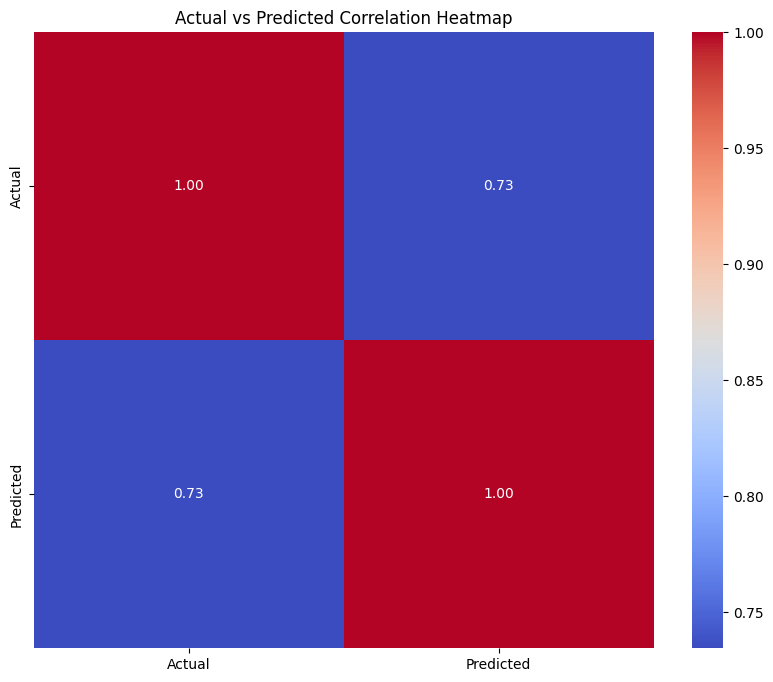

In [ ]:
#In[15]:

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 1)

knn = KNeighborsRegressor()
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
print("Mean Squared Error: ", mean_squared_error(y_test, y_pred).round(2))
print('Root Mean Squared Error: ', np.sqrt(mean_squared_error(y_test, y_pred)).round(2))
print('Mean Absolute Error: ', mean_absolute_error(y_test, y_pred).round(2)) 

results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
plt.figure(figsize=(10, 8))
sns.heatmap(results.corr(), annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Actual vs Predicted Correlation Heatmap")
plt.show()

Fitting 10 folds for each of 200 candidates, totalling 2000 fits

Best Parameters:  {'weights': 'distance', 'p': 1, 'n_neighbors': np.int64(29), 'leaf_size': np.int64(31), 'algorithm': 'auto'}
Best Score (Negative MSE):  -37759090.54107463

Mean Squared Error:  35231745.61
Root Mean Squared Error:  5935.63
Mean Absolute Error:  3862.8


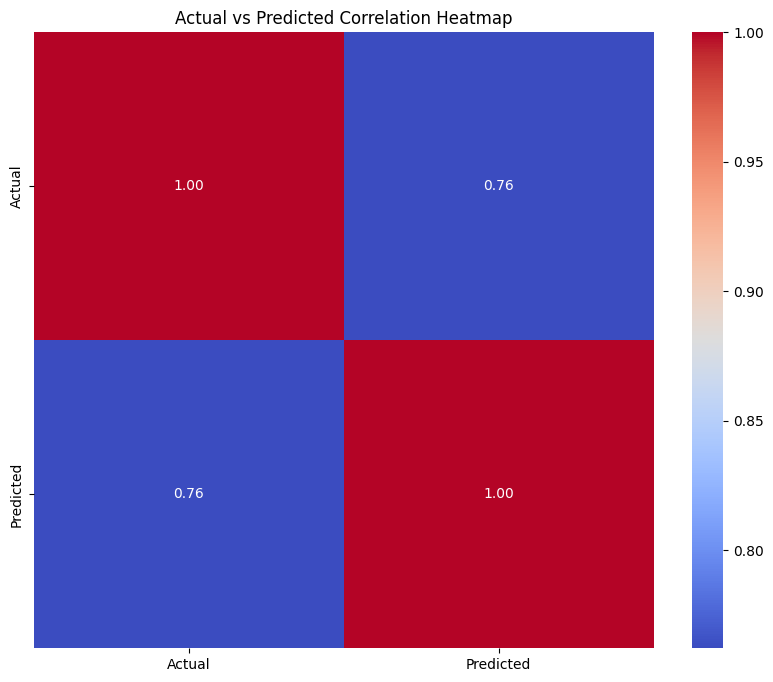

       Actual  Predicted
8579    23900   29386.82
23866   13250    8799.79
34101   11750   12706.12
20901    4200    6486.20
91541    6500   10511.78


In [ ]:
# In[16]:

from sklearn.model_selection import RandomizedSearchCV

parameters = {
    'n_neighbors': np.arange(1, 30, 1),
    'weights': ['uniform', 'distance'],
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
    'leaf_size': np.arange(30, 50, 1),
    'p': [1, 2]  # Manhattan (1) and Euclidean (2) distances
}

knn_grid = RandomizedSearchCV(
    estimator=knn,
    param_distributions=parameters, 
    n_iter=200, 
    cv=10,
    verbose=1,
    random_state=1,
    scoring='neg_mean_squared_error'
)

knn_grid.fit(X_train, y_train)

print("\nBest Parameters: ", knn_grid.best_params_)
print("Best Score (Negative MSE): ", knn_grid.best_score_)

y_pred = knn_grid.predict(X_test)

print("\nMean Squared Error: ", mean_squared_error(y_test, y_pred).round(2))
print("Root Mean Squared Error: ", np.sqrt(mean_squared_error(y_test, y_pred)).round(2))
print("Mean Absolute Error: ", mean_absolute_error(y_test, y_pred).round(2))

results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
plt.figure(figsize=(10, 8))
sns.heatmap(results.corr(), annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Actual vs Predicted Correlation Heatmap")
plt.show()

df1 = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred.round(2)})
print(df1.head())